Loading Hugging Face ViT model...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Using device: CPU
 Initializing GlassBox-ViT (RiseExplainer)...
 Loading and resizing test image (Chelsea the cat)...
 Generating RISE Explanation...


RISE Evaluation: 100%|██████████| 7/7 [01:40<00:00, 14.37s/it]


 RISE EXPLANATION GENERATED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%


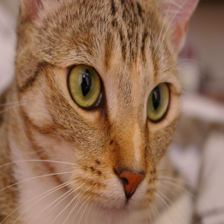

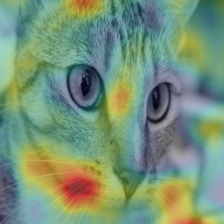

In [ ]:
import torch
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from skimage import data
from IPython.display import display

# Import your custom RISE library
from glassbox_vit.rise_explainer import RiseExplainer

# --- MODEL SETUP ---
print("Loading Hugging Face ViT model...")
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device.upper()}")
model.to(device)
model.eval()

# --- BRIDGE FUNCTION ---
def hf_prediction_function(images_numpy):
    imgs_pil = [Image.fromarray((img).astype('uint8')) for img in images_numpy]
    inputs = processor(images=imgs_pil, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()

# --- INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT (RiseExplainer)...")
# Seed is set so the same masks are always generated for reproducibility
rise_explainer = RiseExplainer(prediction_function=hf_prediction_function, random_state=42)

# --- LOAD TEST IMAGE ---
print(" Loading and resizing test image (Chelsea the cat)...")
image_np = data.chelsea()
test_image = Image.fromarray(image_np).convert("RGB").resize((224, 224))

# --- GENERATE EXPLANATION ---
print(" Generating RISE Explanation...")
# NOTE: Using 200 masks for a quick trial.
# For production/real code, consider increasing to 2000. show_progress displays the progress bar.
result = rise_explainer.generate(
    pil_image=test_image,
    num_masks=200,
    batch_size=32,
    show_progress=True
)

# --- DISPLAY RESULTS IN NOTEBOOK ---
# Extract class names and probabilities
class_names = list(model.config.id2label.values())
predicted_class = class_names[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n RISE EXPLANATION GENERATED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")

# Display the image directly in the notebook cell output
display(test_image)
display(result['rise_image'])